# Módulo 6 — MA(1) a MA(8) sobre los retornos del FTSE100
Dataset: `Index2018.csv` (mismo fichero que usa el Módulo 5 de este curso), columna `ftse`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats.distributions import chi2
from math import sqrt
import warnings
warnings.filterwarnings("ignore")

## Carga y preprocesado

In [2]:
raw_csv_data = pd.read_csv("Index2018.csv")
df_comp = raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date", inplace=True)
df_comp = df_comp.asfreq('B')
df_comp = df_comp.ffill()

df_comp['market_value'] = df_comp.ftse
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

In [3]:
def LLR_test(mod_1, mod_2, DF=1):
    L1 = mod_1.llf
    L2 = mod_2.llf
    LR = (2*(L2-L1))
    p = chi2.sf(LR, DF).round(3)
    return p

## Retornos

In [4]:
df['returns'] = df.market_value.pct_change(1)*100
df.head()

,market_value,returns
date,,
1994-01-07,3445.98,NaN
1994-01-10,3440.58,-0.156704
1994-01-11,3413.77,-0.779229
1994-01-12,3372.02,-1.222988
1994-01-13,3360.01,-0.356166


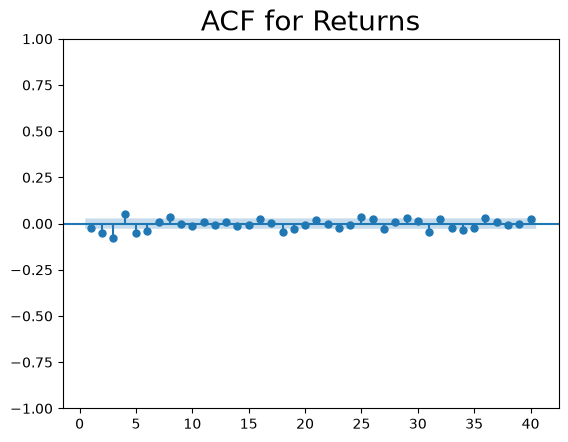

In [5]:
sgt.plot_acf(df.returns[1:], zero=False, lags=40)
plt.title("ACF for Returns", size=20)
plt.show()

## MA(1) para los retornos

In [6]:
model_ret_ma_1 = ARIMA(df.returns[1:], order=(0, 0, 1))
results_ret_ma_1 = model_ret_ma_1.fit()
results_ret_ma_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -7929.595
Date:                Wed, 16 Sep 2026   AIC                          15865.190
Time:                        18:55:26   BIC                          15884.754
Sample:                    01-10-1994   HQIC                         15872.045
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0188      0.016      1.146      0.252      -0.013       0.051
ma.L1         -0.0257      0.009     -3.018      0.003      -0.042      -0.009
sigma2         1.3789      0.014     99.990      0.000       1.352       1.406
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              7852.85
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               2.04   Skew:                            -0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## La escalera MA(2)…MA(8)

In [7]:
resultados = {1: results_ret_ma_1}
for q in range(2, 9):
    modelo = ARIMA(df.returns[1:], order=(0, 0, q))
    resultados[q] = modelo.fit()
    p = LLR_test(resultados[q-1], resultados[q])
    print(f"MA({q})  LL={resultados[q].llf:.3f}  AIC={resultados[q].aic:.3f}  LLR vs MA({q-1}): p={p}")

MA(2)  LL=-7922.864  AIC=15853.728  LLR vs MA(1): p=0.0
MA(3)  LL=-7904.317  AIC=15818.634  LLR vs MA(2): p=0.0


MA(4)  LL=-7898.773  AIC=15809.547  LLR vs MA(3): p=0.001


MA(5)  LL=-7892.823  AIC=15799.645  LLR vs MA(4): p=0.001


MA(6)  LL=-7889.221  AIC=15794.442  LLR vs MA(5): p=0.007


MA(7)  LL=-7889.046  AIC=15796.091  LLR vs MA(6): p=0.554


MA(8)  LL=-7885.603  AIC=15791.205  LLR vs MA(7): p=0.009


In [8]:
print("LLR MA(6) vs MA(8), DF=2:", LLR_test(resultados[6], resultados[8], DF=2))

LLR MA(6) vs MA(8), DF=2: 0.027


## Residuos de MA(8)

In [9]:
df['res_ret_ma_8'] = resultados[8].resid
print("La media de los residuos es " + str(round(df.res_ret_ma_8.mean(), 3)))
print("La varianza de los residuos es " + str(round(df.res_ret_ma_8.var(), 3)))

La media de los residuos es -0.0
La varianza de los residuos es 1.355


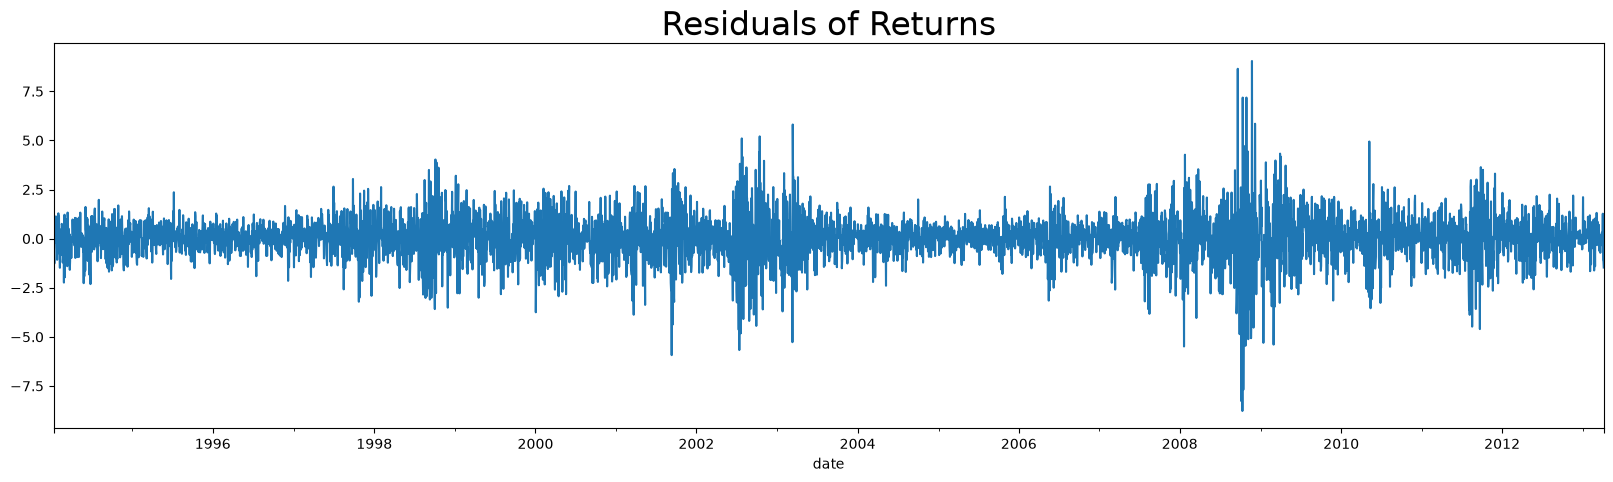

In [10]:
df.res_ret_ma_8[1:].plot(figsize=(20, 5))
plt.title("Residuals of Returns", size=24)
plt.show()

In [11]:
sts.adfuller(df.res_ret_ma_8[1:])

(-70.83777222244072,
 0.0,
 0,
 5019,
 {'1%': np.float64(-3.4316535759402753),
  '5%': np.float64(-2.8621160400844468),
  '10%': np.float64(-2.567076626752987)},
 np.float64(15689.881935682402))

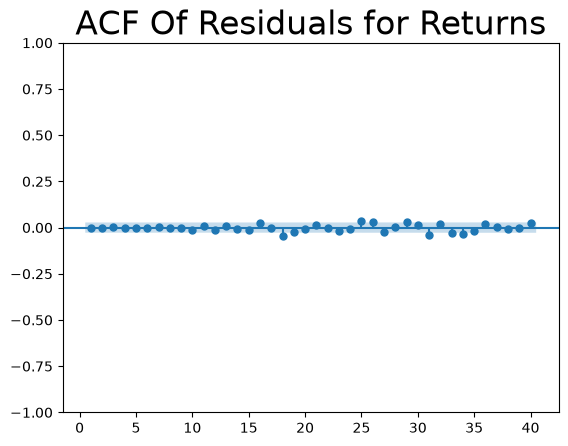

In [12]:
sgt.plot_acf(df.res_ret_ma_8[1:], zero=False, lags=40)
plt.title("ACF Of Residuals for Returns", size=24)
plt.show()

## Precios normalizados y retornos normalizados

In [13]:
benchmark = df.market_value.iloc[0]
df['norm'] = df.market_value.div(benchmark).mul(100)
print(sts.adfuller(df['norm']))

(-1.9041551418836302, 0.3301089327703097, 6, 5014, {'1%': np.float64(-3.4316548765428174), '5%': np.float64(-2.8621166146845334), '10%': np.float64(-2.5670769326348926)}, np.float64(19541.17381480549))


In [14]:
bench_ret = df.returns.iloc[1]
df['norm_ret'] = df.returns.div(bench_ret).mul(100)
print(sts.adfuller(df.norm_ret[1:]))

(-12.770265719497248, 7.798058336037938e-24, 32, 4987, {'1%': np.float64(-3.431661944885779), '5%': np.float64(-2.8621197374408225), '10%': np.float64(-2.5670785949998973)}, np.float64(80114.49116124898))


In [15]:
model_norm_ret_ma_8 = ARIMA(df.norm_ret[1:], order=(0, 0, 8))
results_norm_ret_ma_8 = model_norm_ret_ma_8.fit()
results_norm_ret_ma_8.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:               norm_ret   No. Observations:                 5020
Model:                 ARIMA(0, 0, 8)   Log Likelihood              -40307.614
Date:                Wed, 16 Sep 2026   AIC                          80635.228
Time:                        18:55:29   BIC                          80700.440
Sample:                    01-10-1994   HQIC                         80658.079
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.9731      9.658     -1.240      0.215     -30.902       6.956
ma.L1         -0.0238      0.009     -2.518      0.012      -0.042      -0.005
ma.L2         -0.0495      0.008     -6.030      0.000      -0.066      -0.033
ma.L3         -0.0847      0.008    -10.271      0.000      -0.101      -0.069
ma.L4          0.0488      0.009      5.594      0.000       0.032       0.066
ma.L5         -0.0518      0.008     -6.281      0.000      -0.068      -0.036
ma.L6         -0.0402      0.009     -4.394      0.000      -0.058      -0.022
ma.L7          0.0084      0.009      0.935      0.350      -0.009       0.026
ma.L8          0.0365      0.009      3.866      0.000       0.018       0.055
sigma2      5.538e+05   6087.727     90.971      0.000    5.42e+05    5.66e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              6440.41
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               2.00   Skew:                             0.18
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""